<a href="https://colab.research.google.com/github/MiznaMasood/AI-Powered-Credit-Risk-Prediction-System/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/content/creditcard.csv")

In [4]:
print("Dataset Shape (Rows, Columns):", df.shape)
print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape (Rows, Columns): (17918, 31)

Class Distribution:
Class
0.0    17836
1.0       81
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

# StandardScaler initialize
scaler = StandardScaler()

df["scaled_amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))
df["scaled_time"] = scaler.fit_transform(df["Time"].values.reshape(-1, 1))

In [6]:
df.drop(["Time", "Amount"], axis=1, inplace=True)

In [7]:
print("Updated Dataset Columns:")
print(df.columns)
print("\nUpdated Dataset Head:")
df.head()

Updated Dataset Columns:
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'scaled_amount', 'scaled_time'],
      dtype='object')

Updated Dataset Head:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.434064,-1.409179
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.342606,-1.409179
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.644767,-1.409078
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.295994,-1.409078
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,0.013141,-1.408977


In [8]:
# Check karein ke kis column mein kitni missing values hain
print("Missing values in Target (y):", df["Class"].isnull().sum())


Missing values in Target (y): 1


In [9]:
df.dropna(subset=["Class"], inplace=True)

In [10]:
# Re-assign X aur y
X = df.drop("Class", axis=1)
y = df["Class"]
print(y.isnull().sum())

0


In [11]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

In [12]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\nTrain Set mein Class distribution:")
print(y_train.value_counts())
print("\nTest Set mein Class distribution:")
print(y_test.value_counts())

X_train shape: (14333, 30)
X_test shape:  (3584, 30)

Train Set mein Class distribution:
Class
0.0    14268
1.0       65
Name: count, dtype: int64

Test Set mein Class distribution:
Class
0.0    3568
1.0      16
Name: count, dtype: int64


In [14]:
from imblearn.over_sampling import SMOTE

# SMOTE instance
smote = SMOTE(random_state=42)

# Only apply on Training Data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("--- After SMOTE Training Data distribution ---")
print(y_train_res.value_counts())
print("\nNew Training Features Shape:", X_train_res.shape)

--- After SMOTE Training Data distribution ---
Class
0.0    14268
1.0    14268
Name: count, dtype: int64

New Training Features Shape: (28536, 30)


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Model initialize karein
# n_estimators=100 (100 Decision Trees banenge)
# n_jobs=-1 (Sare CPU cores use honge taake training fast ho)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


rf_model.fit(X_train_res, y_train_res)
print("✅ Model Training Complete!")

✅ Model Training Complete!


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3568
         1.0       0.88      0.94      0.91        16

    accuracy                           1.00      3584
   macro avg       0.94      0.97      0.95      3584
weighted avg       1.00      1.00      1.00      3584

ROC-AUC Score: 0.9999


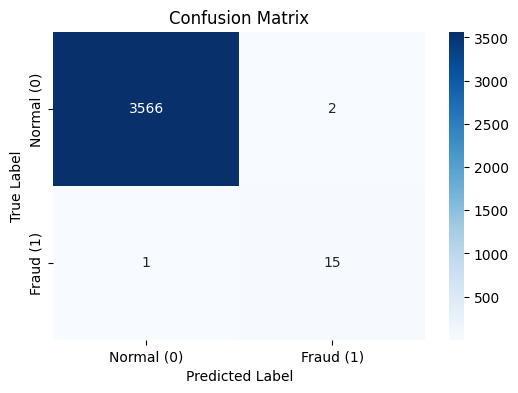

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Test data par predictions karein
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 1. Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. ROC-AUC Score
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# 3. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal (0)", "Fraud (1)"],
    yticklabels=["Normal (0)", "Fraud (1)"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()